In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier # multiple-layer perceptrons 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('D:/Machine Learning/Day-9_Logistic Regression Part 2/ex2data2.csv')
df.shape

(118, 3)

In [4]:
df.head()

,x1,x2,y
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [5]:
X = df[['x1','x2']].values
y = df['y']
X.shape, y.shape

((118, 2), (118,))

In [6]:
# Create a PolynomialFeatures object
degree = 4  # Degree of the polynomial features
poly = PolynomialFeatures(degree)

# Transform the data to include polynomial features
X_poly = poly.fit_transform(X)


In [7]:
X_poly.shape

(118, 15)

In [25]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape, X_test.shape

((94, 15), (24, 15))

In [42]:
# Create a neural network model
model = MLPClassifier(hidden_layer_sizes=(25, 25), activation='relu', solver='sgd',
                      max_iter=10000, random_state=42, tol=1e-6,                 # smaller tolerance → more training
    n_iter_no_change=50)      

# Train the model
model.fit(X_train, y_train)

C:\Users\thein\anaconda3\envs\Data\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='tanh', hidden_layer_sizes=(25, 25), max_iter=10000,
              n_iter_no_change=50, random_state=42, solver='sgd', tol=1e-06)

In [43]:
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[11  1]
 [ 2 10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.91      0.83      0.87        12

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.87        24
weighted avg       0.88      0.88      0.87        24



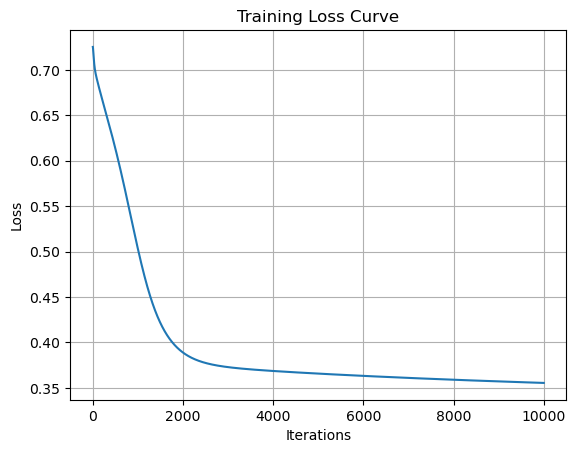

In [44]:
# Optional: Visualize the training loss over iterations
plt.plot(model.loss_curve_)
plt.title('Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid()
plt.show()